# Daily Swing Screener - Snap-Back (mean-reversion) Model

**Open this every day, run all cells, read the BUY NOW / CLOSE TO BUY tables.**

This model was **rebuilt from an empirical study** (below). The old version gated everything
behind a 200-day moving average, so signals showed up once in a blue moon. This one is a
**mean-reversion swing model** - it buys *stretched, oversold dips* and sells when they snap
back - which tested with a **higher win rate and far more consistent triggers**.

### What it uses (only the variables that actually mattered in testing)
- **RSI-2 oversold** - the classic short-term mean-reversion oscillator (Connors). ~68% win rate on its own.
- **Stretch from the 20/21 band, in standard deviations** (`z_band`). Because *stocks retrace*,
  a name stretched **below** the band tends to snap back toward it; a name far **above** it tends
  to test/return to it. **No requirement to be above the band.**
- **Volume surge** (today's volume vs its 20-day average) - buying-power / bottom confirmation.
  In testing this lifted avg return per trade ~0.9% -> ~1.3% and profit factor 1.6 -> 1.8.
- A **soft** trend context (>50-SMA, rising 20-SMA) - a score nudge, **not a gate**. **No 200-SMA.**

### Buckets
- **BUY NOW** - a dip fired today *and* this name has a **proven historical snap-back win rate (>=58%)**. Frequent + high win rate.
- **CLOSE TO BUY** - a dip fired with a moderate/unproven edge, or price is sliding into the buy zone.
- **HOLD** - constructive uptrend, no fresh dip, not extended.
- **TAKE PROFIT / SELL** - reverted (RSI-2 > 70) or extended (>= +2 sigma above the band).
- **WATCH** - neutral.

> **Research only, not financial advice.**

```bash
pip install -r requirements.txt
```

## 0. Why this model - the empirical study

Backtested candidate swing setups over **6 years on 45 liquid tickers** (mega-caps, popular WSB
names, sector ETFs), entering at the next open and exiting on a **snap-back** (RSI-2 back above 70,
or a close back above the 5-day SMA), with a protective stop. Win rate + how often it fires:

| Setup (daily bars, no 200-SMA) | Win % | Trades / yr / ticker | Avg % / trade |
|---|---|---|---|
| **RSI-2 < 10** (oversold) | **~68%** | ~12 (very frequent) | +0.9% |
| **Stretch z <= -2 below band** | **~68%** | ~4 | +1.3% |
| **RSI-2 < 10 + volume >= 1.5x** | **~68%** | ~4 | **+1.3%** (volume lifts returns) |
| z <= -1.5 & up-close | ~69% | ~3 | +0.8% |
| _old: 200-SMA-gated breakout_ | _~52%_ | _rare_ | _mixed_ |

Takeaways baked into the model: **mean-reversion dips beat trend-gated breakouts**, **volume surge
adds value**, **standard-deviation stretch from the band is a strong, symmetric signal**, and the
**200-SMA gate was the thing making signals rare** - so it's gone. Each ticker below also carries its
own snap-back backtest, and **BUY NOW only shows names whose history clears a 58% win rate.**

## 1. Config - edit me

In [1]:
TOP_N    = 200     # how many WSB tickers to scan
PERIOD   = "4y"    # daily history length (enough to backtest each name's snap-back edge)
INTERVAL = "1d"
OUTDIR   = "results"

from wsb_screener import quant_screener as qscr
from wsb_screener.quant_report import build_markdown
from wsb_screener.data import get_wsb_tickers, download_history
import pandas as pd
pd.set_option("display.max_rows", 250, "display.width", 260, "display.max_columns", 60)

## 2. Fetch the WSB universe + daily price history

In [2]:
tickers = get_wsb_tickers(TOP_N)
metas   = {t["ticker"]: t for t in tickers}
print(f"Top {len(metas)} r/wallstreetbets tickers by mention count")
print(", ".join(list(metas)[:25]), "...")

hist = download_history(list(metas), period=PERIOD, interval=INTERVAL)
print(f"\nDownloaded daily price data for {len(hist)}/{len(metas)} tickers")

Top 200 r/wallstreetbets tickers by mention count
MU, SPY, NVDA, MSFT, SNDK, QQQ, SPCX, META, NBIS, DTE, WEN, AMD, ORCL, AVGO, TSLA, RKLB, SOXL, PENG, GOOG, GOOGL, IT, SMH, ASTS, INTC, AM ...


$RE: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}


$DAY: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")


$OS: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")


...

['OG']: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")


$GPS: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")



1 Failed download:


['GPS']: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")



Downloaded daily price data for 195/200 tickers


## 3. Run the model (dip trigger -> per-name backtest -> bucket)

In [3]:
df = qscr.run_screener(hist, metas)
signal_date = df["signal_date"].dropna().mode().iloc[0]
print("Latest daily bar:", signal_date)
df["group"].value_counts()

  ...screened 25/200


  ...screened 50/200


  ...screened 75/200


  ...screened 100/200


  ...screened 125/200


  ...screened 150/200


  ...screened 175/200


  ...screened 200/200
Latest daily bar: 2026-07-09


group
TAKE PROFIT / SELL    64
HOLD                  62
WATCH                 55
BUY NOW                7
SKIPPED                7
CLOSE TO BUY           5
Name: count, dtype: int64

## 4. BUY NOW - dips firing today in names with a proven snap-back edge
Oversold (RSI-2) and/or stretched >= 1.5 sigma below the band, and this name has historically
snapped back with a **>= 58% win rate**. Ranked best win rate first. Act at next open.

In [4]:
buy_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%",
            "vol_surge","bt_trades","bt_winrate_%","bt_expectancy_$","band_read","note"]
df[df.group=="BUY NOW"][buy_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,vol_surge,bt_trades,bt_winrate_%,bt_expectancy_$,band_read,note
0,1,WEN,Wendy’s Company,7.45,48.6,8.2,-0.04,-0.42,0.11,64.0,70.3,11.84,at the band,dip buy (70% hist. win): RSI-2 8 (oversold) (a...
1,2,COST,Costco,910.50,47.9,9.4,-2.25,-4.88,0.74,49.0,67.3,7.20,"-2.3 sigma below band - stretched, bounce zone","dip buy (67% hist. win): RSI-2 9 (oversold), -..."
2,3,AZZ,AZZ,138.35,53.9,4.6,-1.98,-8.20,0.65,52.0,65.4,9.09,"-2.0 sigma below band - stretched, bounce zone","dip buy (65% hist. win): RSI-2 5 (oversold), -..."
3,4,CC,Chemours,18.17,31.7,21.0,-1.61,-12.09,0.13,69.0,63.8,10.03,"-1.6 sigma below band - stretched, bounce zone",dip buy (64% hist. win): -1.6 sigma below band...
4,5,FAST,Fastenal,46.39,43.2,8.2,-0.32,-0.66,0.30,56.0,62.5,4.35,at the band,dip buy (62% hist. win): RSI-2 8 (oversold) (a...
5,6,PEP,Pepsico,137.43,42.7,11.0,-1.70,-3.46,0.71,55.0,61.8,0.64,"-1.7 sigma below band - stretched, bounce zone",dip buy (62% hist. win): -1.7 sigma below band...
6,7,ZROZ,Pimco Exchange Traded Fund - PIMCO 25+ Year Ze...,61.08,43.7,0.6,-1.42,-2.68,0.15,64.0,59.4,0.49,-1.4 sigma below band - pulling back toward band,dip buy (59% hist. win): RSI-2 1 (oversold) (a...


## 5. CLOSE TO BUY - dips with a moderate edge, or sliding into the zone
Either a dip fired but the historical edge is moderate/unproven, or price is getting oversold /
stretching toward the band. Watch for the snap-back.

In [5]:
near_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%",
             "vol_surge","bt_winrate_%","band_read","note"]
df[df.group=="CLOSE TO BUY"][near_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,vol_surge,bt_winrate_%,band_read,note
7,1,TLT,BlackRock Institutional Trust Company N.A. - B...,84.43,51.0,15.6,-1.36,-1.41,0.27,65.6,-1.4 sigma below band - pulling back toward band,RSI-2 16 sliding into oversold; -1.4 sigma bel...
8,2,RXT,Rackspace Technology,4.84,53.5,8.6,-1.92,-27.81,1.40,53.5,"-1.9 sigma below band - stretched, bounce zone","dip fired (54% hist. win): RSI-2 9 (oversold),..."
9,3,REAL,The RealReal,10.54,46.2,16.5,-0.78,-7.30,0.09,50.7,-0.8 sigma below band - pulling back toward band,RSI-2 16 sliding into oversold -- watch for th...
10,4,LUNR,Intuitive Machines,17.10,45.6,10.6,-1.33,-27.65,0.31,49.3,-1.3 sigma below band - pulling back toward band,RSI-2 11 sliding into oversold; -1.3 sigma bel...
11,5,UP,Wheels Up,7.97,49.1,23.4,-0.08,-0.68,0.13,40.7,at the band,RSI-2 23 sliding into oversold -- watch for th...


## 6. HOLD / TAKE PROFIT-SELL / WATCH
- **HOLD** - constructive uptrend, no fresh dip; hold if long, wait for a pullback.
- **TAKE PROFIT / SELL** - reverted (RSI-2 > 70) or extended (>= +2 sigma above band); trim if long.
- **WATCH** - neutral.

In [6]:
hold_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","mom_63_%","bt_winrate_%","bt_expectancy_$"]
sell_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%","band_read","note"]
watch_cols= ["group_rank","ticker","name","close","score","rsi2","z_band","above_50","mom_63_%"]
from IPython.display import display
print("HOLD");               display(df[df.group=="HOLD"][hold_cols].head(20))
print("TAKE PROFIT / SELL"); display(df[df.group=="TAKE PROFIT / SELL"][sell_cols].head(20))
print("WATCH");              display(df[df.group=="WATCH"][watch_cols].head(20))

HOLD


,group_rank,ticker,name,close,score,rsi2,z_band,mom_63_%,bt_winrate_%,bt_expectancy_$
12,1,DE,Deere & Company,599.60,43.7,29.1,-0.05,-1.3,69.2,5.84
13,2,GE,General Electric,360.45,43.5,36.7,0.20,17.2,77.5,19.48
14,3,NVO,Novo Nordisk,49.03,43.5,41.6,0.83,30.4,68.9,10.49
15,4,MA,Mastercard,521.61,43.5,31.7,0.83,3.0,66.0,6.57
16,5,FCEL,FuelCell Energy,23.91,43.5,36.4,-0.01,273.0,52.5,2.96
17,6,HD,Home Depot,339.61,43.5,36.5,0.10,1.0,62.7,0.68
18,7,LOVE,LoveSac,17.04,43.5,37.6,0.56,9.7,60.6,-5.74
19,8,EW,Edwards Lifesciences,92.27,41.6,13.0,0.70,12.9,72.9,11.47
20,9,CIA,Citizens Inc,5.52,40.3,18.7,-0.88,1.1,64.6,13.71
21,10,INTC,Intel,112.55,39.8,41.1,-1.02,90.9,62.5,8.08


TAKE PROFIT / SELL


,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,band_read,note
74,1,ADM,Archer Daniels Midland,80.61,30.8,99.5,1.47,3.39,+1.5 sigma above band - riding above support,exit signal: RSI-2 100 reverted
75,2,BABA,Alibaba,111.87,26.7,98.5,0.96,6.16,+1.0 sigma above band - riding above support,exit signal: RSI-2 98 reverted
76,3,NET,Cloudflare,274.11,35.0,97.4,1.91,11.91,+1.9 sigma above band - riding above support,exit signal: RSI-2 97 reverted
77,4,DFTX,Definium Therapeutics,47.28,39.3,95.7,0.98,20.54,+1.0 sigma above band - riding above support,exit signal: RSI-2 96 reverted
78,5,HPE,Hewlett Packard Enterprise,47.53,33.9,94.5,0.85,4.16,+0.9 sigma above band - riding above support,exit signal: RSI-2 94 reverted
79,6,EBAY,eBay,117.07,35.0,94.1,1.89,5.21,+1.9 sigma above band - riding above support,exit signal: RSI-2 94 reverted
80,7,DELL,Dell,452.48,35.0,93.5,2.29,9.34,"+2.3 sigma above band - extended, may retrace/...",exit signal: RSI-2 94 reverted
81,8,AVGO,Broadcom,401.23,23.6,93.3,1.41,4.36,+1.4 sigma above band - riding above support,exit signal: RSI-2 93 reverted
82,9,API,Agora.io,4.28,33.9,93.1,0.67,2.36,+0.7 sigma above band - riding above support,exit signal: RSI-2 93 reverted
83,10,CBOE,Cboe,265.93,26.7,92.9,0.17,1.26,at the band,exit signal: RSI-2 93 reverted


WATCH


,group_rank,ticker,name,close,score,rsi2,z_band,above_50,mom_63_%
138,1,RKLB,Rocket Lab USA,84.76,34.4,31.9,-1.21,False,22.7
139,2,UAMY,United States Antimony Corporation,6.78,34.4,34.9,-1.29,False,-23.4
140,3,RUN,Sunrun,12.16,34.4,35.8,-1.27,False,-12.3
141,4,DIS,Walt Disney,95.94,32.5,15.0,-1.28,False,-2.5
142,5,HBM,Hudbay Minerals,21.42,30.2,49.0,-1.11,False,-9.9
143,6,KORU,Direxion Shares ETF Trust - Direxion Daily Sou...,563.75,30.2,46.5,-1.03,False,39.2
144,7,OKLO,Oklo,48.90,30.2,54.3,-1.26,False,-2.6
145,8,APLD,Applied Blockchain,32.79,30.2,65.4,-1.11,False,18.0
146,9,RDW,Redwire,10.69,30.2,47.8,-1.03,False,11.2
147,10,OR,Osisko Gold Royalties,30.08,30.2,54.8,-1.08,False,-25.1


## 7. Save the scan (CSV + Markdown report)

In [7]:
import os
os.makedirs(OUTDIR, exist_ok=True)
df.to_csv(f"{OUTDIR}/wsb_quant_screen.csv", index=False)
with open(f"{OUTDIR}/wsb_quant_report.md", "w") as f:
    f.write(build_markdown(df, len(metas), signal_date))
print("wrote", f"{OUTDIR}/wsb_quant_screen.csv", "and", f"{OUTDIR}/wsb_quant_report.md")

wrote results/wsb_quant_screen.csv and results/wsb_quant_report.md


## 8. (Optional) Drill into one ticker
Price + the 20/21 support band + the 50-SMA, with the snap-back backtest's buy/sell markers, plus
a lower panel showing **RSI-2** (oversold line) and the latest stretch / component breakdown.

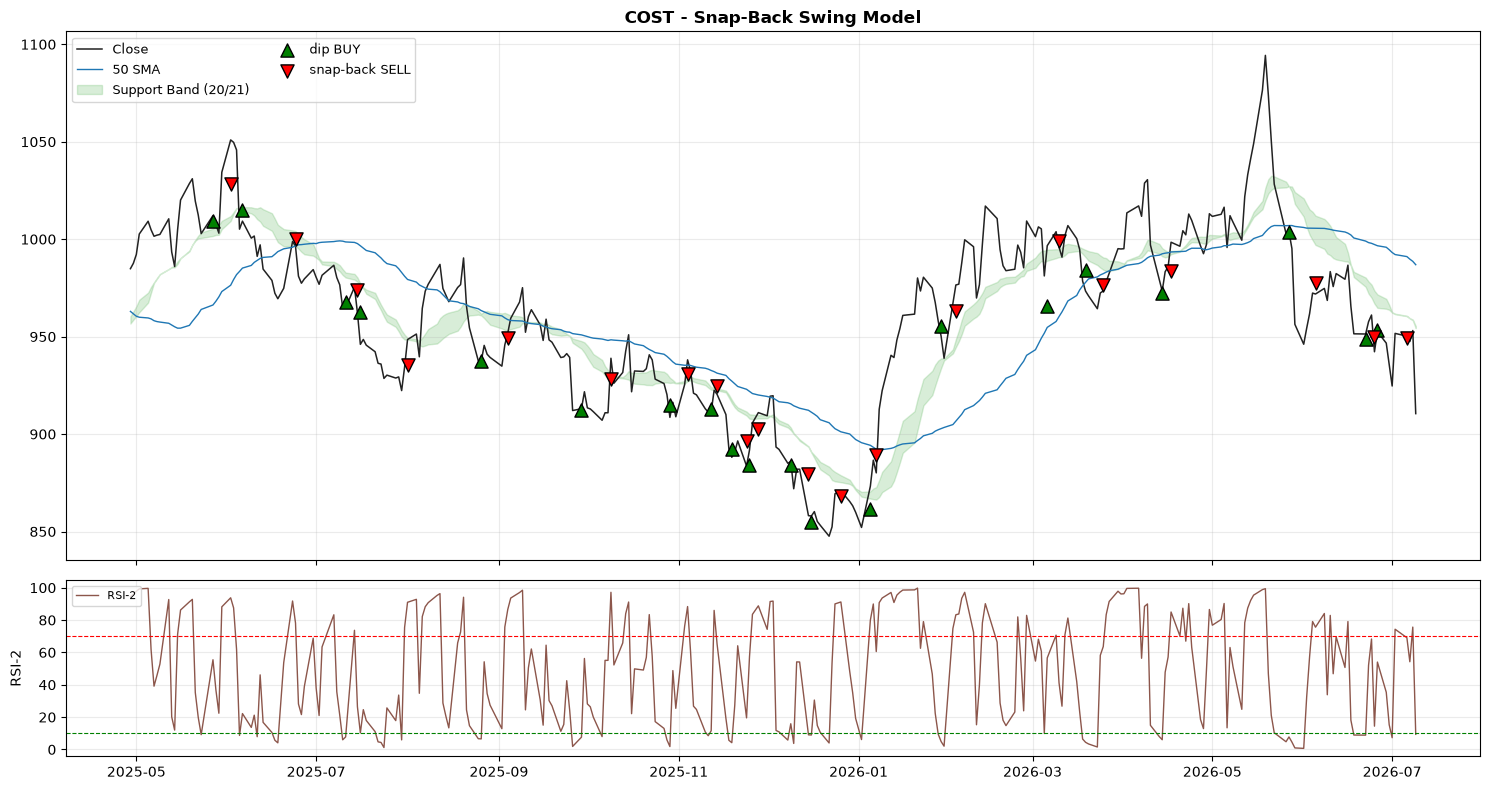

COST: score=47.9 | RSI-2=9.4 | z_band=-2.25 (-2.3 sigma below band - stretched, bounce zone) | vol_surge=0.74x -> BUY NOW
component scores (0-100): {'oversold': 85.0, 'stretch': 90.0, 'volume': 14.0, 'reversal': 0.0, 'trend': 0.0}
this ticker's snap-back backtest: {'Total Trades': 49, 'Win Rate %': 67.3, 'Total P&L $': np.float64(352.77), 'Avg Win $': np.float64(17.54), 'Avg Loss $': np.float64(-14.13), 'Profit Factor': np.float64(2.56), 'Expectancy $': np.float64(7.2), 'Avg Bars Held': np.float64(4.2), 'Max Drawdown $': np.float64(-70.29), 'Return/Trade %': np.float64(0.72)}


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from wsb_screener.quant_core import swing_backtest, live_signal, compute_stats, RSI_OS, RSI_EXIT

SYMBOL = "COST"   # <- pick any ticker from the tables above (the WSB universe changes daily)
if SYMBOL not in set(df.ticker) or SYMBOL not in hist:
    pref = [x for x in df[df.group.isin(["BUY NOW","CLOSE TO BUY"])].ticker if x in hist]
    pref = pref or [x for x in df.ticker if x in hist]
    SYMBOL = pref[0]
    print(f"(SYMBOL not in today's table -> showing {SYMBOL}; edit SYMBOL to any ticker above)")

d, t = swing_backtest(hist[SYMBOL])
view = d.tail(300)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15,8), sharex=True, gridspec_kw={"height_ratios":[3,1]})
ax.plot(view.Date, view.Close, color="#222", lw=1.1, label="Close")
ax.plot(view.Date, view.SMA50, color="#1f77b4", lw=1.0, label="50 SMA")
ax.fill_between(view.Date, view.band_bot, view.band_top, color="#2ca02c", alpha=0.18, label="Support Band (20/21)")
tv = t[t.entry_date >= view.Date.iloc[0]] if not t.empty else t
if not tv.empty:
    ax.scatter(tv.entry_date, tv.entry_price, marker="^", s=90, color="green", edgecolor="k", zorder=5, label="dip BUY")
    ax.scatter(tv.exit_date,  tv.exit_price,  marker="v", s=90, color="red",   edgecolor="k", zorder=5, label="snap-back SELL")
ax.set_title(f"{SYMBOL} - Snap-Back Swing Model", weight="bold"); ax.legend(loc="upper left", ncol=2, fontsize=9); ax.grid(alpha=0.25)
ax2.plot(view.Date, view.RSI2, color="#8c564b", lw=1.0, label="RSI-2")
ax2.axhline(RSI_OS, color="green", ls="--", lw=0.8); ax2.axhline(RSI_EXIT, color="red", ls="--", lw=0.8)
ax2.set_ylabel("RSI-2"); ax2.grid(alpha=0.25); ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

sig = live_signal(hist[SYMBOL])
print(f"{SYMBOL}: score={sig['score']} | RSI-2={sig['rsi2']} | z_band={sig['z_band']} ({sig['band_read']}) | vol_surge={sig['vol_surge']}x -> {df[df.ticker==SYMBOL].group.iloc[0]}")
print("component scores (0-100):", {k[2:]: sig[k] for k in ("s_oversold","s_stretch","s_volume","s_reversal","s_trend")})
print("this ticker's snap-back backtest:", compute_stats(t))